# Part 2: RFM Segmentation & Retention Strategy

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
os.makedirs('charts', exist_ok=True)

## 1. Load Datasets

In [5]:
customers = pd.read_csv("data/customers.csv")
orders = pd.read_csv("data/orders.csv")
tickets = pd.read_csv("data/support_tickets.csv")
web = pd.read_csv("data/web_events_snapshot.csv")
intervention = pd.read_csv("data/intervention_history.csv")
churn = pd.read_csv("data/churn_labels.csv")

In [6]:
# date conversion
snapshot_date = pd.Timestamp("2025-09-30")
orders["order_date"] = pd.to_datetime(orders["order_date"])
customers["signup_date"] = pd.to_datetime(customers["signup_date"])


In [ ]:
# removing duplicates and post-snapshot
orders_clean = orders[(orders['order_date'] <= snapshot_date) &
    (~orders['order_id'].str.endswith('_DUP'))].copy()

print(f'Clean orders: {len(orders_clean)}')
print(f'Customers: {len(customers)}')

Clean orders: 8128
Customers: 2400


## 2. Building RFM Table

In [8]:
rfm = orders_clean.groupby('customer_id').agg(
    last_order_date = ('order_date', 'max'),
    frequency       = ('order_id', 'count'),
    monetary        = ('gross_amount', 'sum')
).reset_index()

rfm['recency'] = (snapshot_date - rfm['last_order_date']).dt.days
rfm.drop(columns='last_order_date', inplace=True)

print('RFM summary:')
print(rfm[['recency','frequency','monetary']].describe().round(2))

RFM summary:
       recency  frequency  monetary
count  2400.00    2400.00   2400.00
mean     87.38       3.39   2547.12
std      80.14       2.38   2127.69
min       0.00       1.00    149.00
25%      25.00       1.00    954.52
50%      66.00       3.00   2010.71
75%     129.00       5.00   3562.12
max     562.00      16.00  27215.92


In [9]:
rfm.head(3)

,customer_id,frequency,monetary,recency
0,CUST00001,6,2955.57,107
1,CUST00002,1,581.00,40
2,CUST00003,1,649.98,171


## 3. RFM Scoring

Each customer is assigned a score from 1 to 5 for Recency, Frequency, and Monetary value.

Higher scores indicate better customer engagement. The three scores are added together to create an overall RFM score.

In [10]:
# Recency: lower days = higher score
rfm['R'] = pd.qcut(rfm['recency'], q=5, labels=[5,4,3,2,1]).astype(int)

# Frequency and Monetary: higher = higher score
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_score'] = rfm['R'] + rfm['F'] + rfm['M']

print('Score distribution:')
print(rfm['RFM_score'].value_counts().sort_index())
print(f'\nScore range: {rfm["RFM_score"].min()} to {rfm["RFM_score"].max()}')

Score distribution:
RFM_score
3      67
4     105
5     164
6     225
7     294
8     246
9     256
10    232
11    228
12    205
13    164
14    121
15     93
Name: count, dtype: int64

Score range: 3 to 15


## 4. Additional Customer Signals

In [11]:
# Signal 1: support ticket behaviour
ticket_agg = tickets.groupby('customer_id').agg(
    ticket_count   = ('ticket_id', 'count'),
    avg_sentiment  = ('sentiment_score', 'mean'),
    reopen_rate    = ('reopened', 'mean')
).reset_index()

# Signal 2: return rate + discount behaviour
order_signals = orders_clean.groupby('customer_id').agg(
    return_rate  = ('returned', 'mean'),
    avg_discount = ('discount_pct', 'mean')
).reset_index()

print('Customers with at least 1 ticket:', len(ticket_agg))
print('Avg return rate:', order_signals['return_rate'].mean().round(3))

Customers with at least 1 ticket: 1247
Avg return rate: 0.068


## 5. Master table

In [12]:
master = customers.merge(rfm, on='customer_id', how='left')
master = master.merge(ticket_agg, on='customer_id', how='left')
master = master.merge(order_signals, on='customer_id', how='left')
master = master.merge(web.drop(columns='snapshot_date'), on='customer_id', how='left')
master = master.merge(intervention.drop(columns='snapshot_date'), on='customer_id', how='left')
master = master.merge(churn[['customer_id','churn_next_60d']], on='customer_id', how='left')

master['ticket_count'] = master['ticket_count'].fillna(0)
master['return_rate']  = master['return_rate'].fillna(0)

print(f'Master shape: {master.shape}')
master[['customer_id','R','F','M','RFM_score','recency','frequency','monetary',
        'ticket_count','avg_sentiment','return_rate','sessions_30d']].head()

Master shape: (2400, 33)


,customer_id,R,F,M,RFM_score,recency,frequency,monetary,ticket_count,avg_sentiment,return_rate,sessions_30d
0,CUST00001,2,5,4,11,107,6,2955.57,2.0,0.14,0.166667,1
1,CUST00002,4,1,1,6,40,1,581.00,1.0,0.00,0.000000,8
2,CUST00003,1,1,1,3,171,1,649.98,0.0,NaN,0.000000,1
3,CUST00004,2,1,3,6,131,1,1604.04,0.0,NaN,0.000000,1
4,CUST00005,4,3,3,10,38,4,2550.91,1.0,-1.00,0.000000,18


## 6. Customer Segmentation Approach

Segments are assigned using a rule-based approach combining RFM scores with support ticket count and sentiment.

| Segment                            | Definition                                                                                                                                                                                                        |
| ---------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Champions**                      | Customers with high recency, frequency, and monetary scores (R ≥ 4, F ≥ 4, M ≥ 4). These customers purchase frequently, spend more than average, and have interacted with the brand recently.                     |
| **High-Value Unhappy**             | Customers with strong RFM performance (R ≥ 3, F ≥ 3, M ≥ 3) but who have raised multiple support tickets and show negative sentiment. Although valuable, they may be at risk if service issues are not addressed. |
| **Loyal Customers**                | Customers with consistently good RFM scores (R ≥ 3, F ≥ 3, M ≥ 3) and no significant complaint history. These customers form a stable part of the customer base.                                                  |
| **At-Risk Customers**              | Customers who were previously active purchasers (F ≥ 3) but have not made a recent purchase (R ≤ 2). Their past engagement suggests that they may be recoverable through targeted interventions.                  |
| **Dormant Customers**              | Customers with low recency and frequency scores and no recent website activity. These customers appear disengaged across both purchase and digital channels.                                                      |
| **Discount-Sensitive Customers**   | Customers who make repeat purchases but tend to buy only when substantial discounts are offered. Their average discount usage is relatively high compared with the rest of the customer base.                     |
| **New / Low-Engagement Customers** | Customers who do not clearly fit into any of the above categories. They typically have limited purchase history and relatively low engagement signals.                                                            |




In [13]:
def assign_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    tc   = row['ticket_count']
    sent = row['avg_sentiment'] if not pd.isna(row['avg_sentiment']) else 0
    sess = row['sessions_30d']
    disc = row['avg_discount'] if not pd.isna(row['avg_discount']) else 0

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        if tc >= 2 and sent < 0:
            return 'High-Value Unhappy'
        return 'Loyal Customers'
    elif r <= 2 and f >= 3:
        return 'At-Risk'
    elif r <= 2 and f <= 2 and sess == 0:
        return 'Dormant'
    elif disc >= 0.4 and f >= 2:
        return 'Discount-Sensitive'
    else:
        return 'New / Low-Engagement'

master['segment'] = master.apply(assign_segment, axis=1)

print('Segment counts:')
print(master['segment'].value_counts())

Segment counts:
segment
New / Low-Engagement    913
At-Risk                 571
Champions               344
Loyal Customers         326
High-Value Unhappy      116
Discount-Sensitive       76
Dormant                  54
Name: count, dtype: int64


## 7. Segment Analysis

In [14]:
seg_stats = master.groupby('segment').agg(
    count         = ('customer_id','count'),
    churn_rate    = ('churn_next_60d','mean'),
    avg_recency   = ('recency','mean'),
    avg_frequency = ('frequency','mean'),
    avg_monetary  = ('monetary','mean'),
    avg_tickets   = ('ticket_count','mean')
).round(2)
seg_stats['churn_rate_pct'] = (seg_stats['churn_rate'] * 100).round(1)
print(seg_stats.drop(columns='churn_rate').to_string())

                      count  avg_recency  avg_frequency  avg_monetary  avg_tickets  churn_rate_pct
segment                                                                                           
At-Risk                 571       161.25           4.48       3386.77         1.03            78.0
Champions               344        20.65           6.37       4915.91         1.46            10.0
Discount-Sensitive       76        65.74           1.63        865.21         0.39            47.0
Dormant                  54       202.69           1.30       1064.46         0.30            83.0
High-Value Unhappy      116        56.24           5.59       4128.26         2.43            34.0
Loyal Customers         326        47.30           3.97       3064.24         0.57            24.0
New / Low-Engagement    913        79.56           1.36        971.64         0.35            49.0


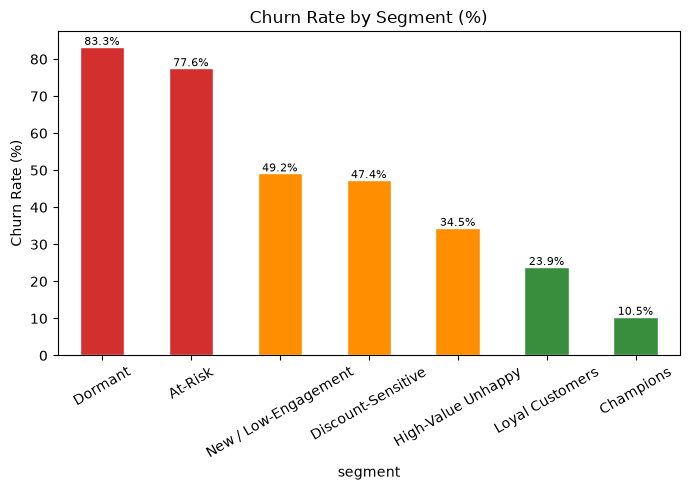

In [15]:
# churn rate by segment
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

cr = master.groupby('segment')['churn_next_60d'].mean().sort_values(ascending=False) * 100
colors = ['#d32f2f' if v > 60 else '#ff8f00' if v > 30 else '#388e3c' for v in cr.values]
cr.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Churn Rate by Segment (%)')
ax.set_ylabel('Churn Rate (%)')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+0.05, p.get_height()+0.5), fontsize=8)

plt.tight_layout()
plt.savefig('charts/chart1_churn_rate.png', dpi=120)
plt.show()

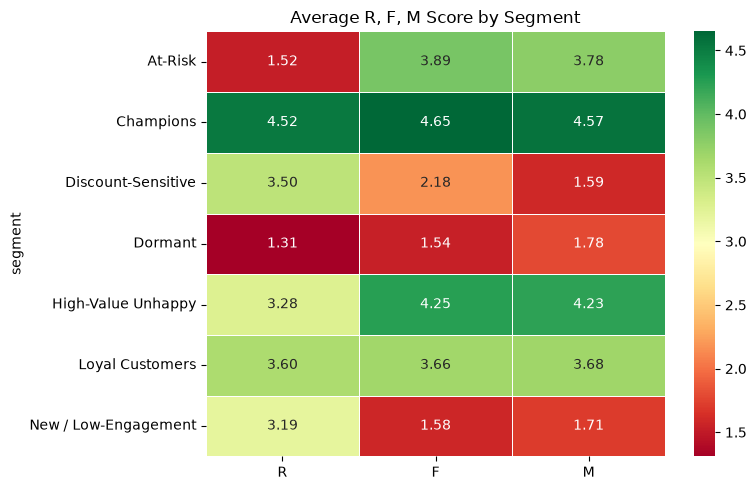

In [16]:
# RFM heatmap by segment
rfm_means = master.groupby('segment')[['R','F','M']].mean().round(2)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(rfm_means, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, linewidths=0.5)
ax.set_title('Average R, F, M Score by Segment')
plt.tight_layout()
plt.savefig('charts/chart2_rfm_heatmap.png', dpi=120)
plt.show()

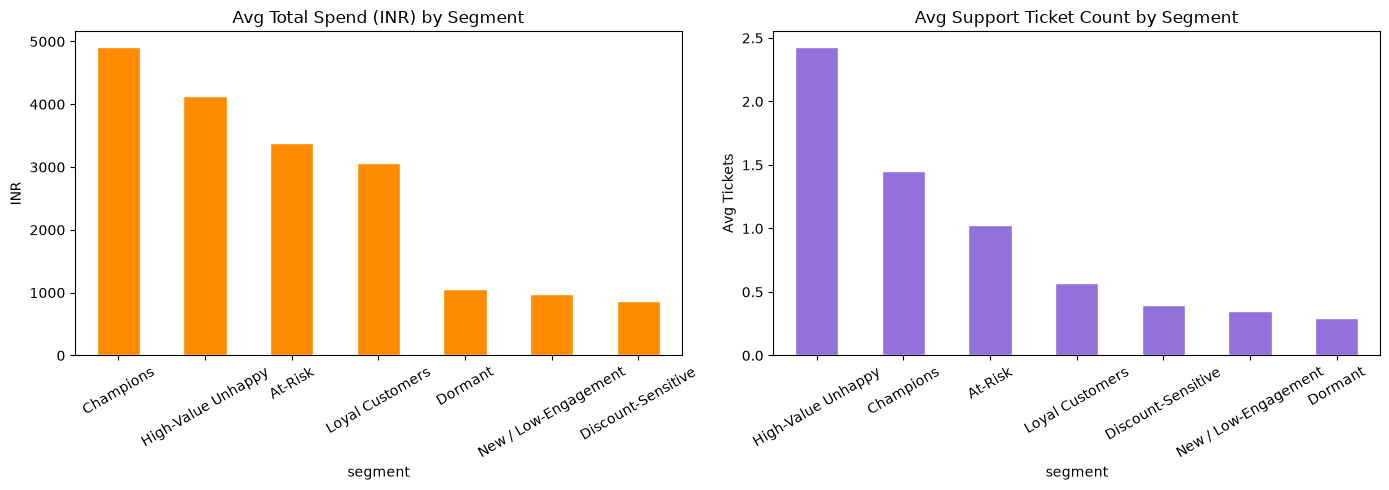

In [17]:
# avg monetary value and ticket count per segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mon = master.groupby('segment')['monetary'].mean().sort_values(ascending=False)
mon.plot(kind='bar', ax=axes[0], color='darkorange', edgecolor='white')
axes[0].set_title('Avg Total Spend (INR) by Segment')
axes[0].set_ylabel('INR')
axes[0].tick_params(axis='x', rotation=30)

tc = master.groupby('segment')['ticket_count'].mean().sort_values(ascending=False)
tc.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Avg Support Ticket Count by Segment')
axes[1].set_ylabel('Avg Tickets')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('charts/chart3_spend_tickets.png', dpi=120)
plt.show()

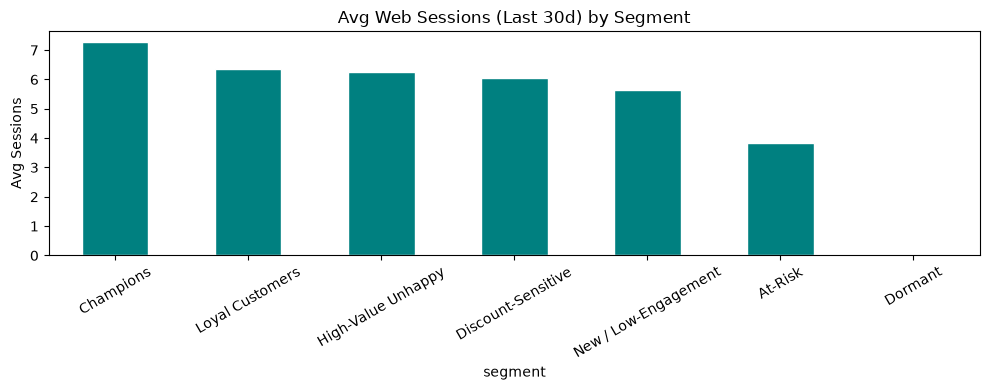

In [18]:
# web sessions by segment
fig, ax = plt.subplots(figsize=(10, 4))
sess = master.groupby('segment')['sessions_30d'].mean().sort_values(ascending=False)
sess.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Avg Web Sessions (Last 30d) by Segment')
ax.set_ylabel('Avg Sessions')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('charts/chart4_web_sessions.png', dpi=120)
plt.show()

In [19]:
# Revenue at risk = avg_monetary * churn_rate * count
budget = master.groupby('segment').agg(
    count      = ('customer_id','count'),
    churn_rate = ('churn_next_60d','mean'),
    avg_spend  = ('monetary','mean')
).reset_index()

budget['revenue_at_risk'] = (budget['avg_spend'] * budget['churn_rate'] * budget['count']).round(0)
budget = budget.sort_values('revenue_at_risk', ascending=False)

print('Revenue at risk by segment:')
print(budget[['segment','count','churn_rate','avg_spend','revenue_at_risk']].to_string())

Revenue at risk by segment:
                segment  count  churn_rate    avg_spend  revenue_at_risk
0               At-Risk    571    0.775832  3386.773187        1500341.0
6  New / Low-Engagement    913    0.491785   971.637864         436265.0
5       Loyal Customers    326    0.239264  3064.235368         239010.0
1             Champions    344    0.104651  4915.905901         176973.0
4    High-Value Unhappy    116    0.344828  4128.258190         165130.0
3               Dormant     54    0.833333  1064.463519          47901.0
2    Discount-Sensitive     76    0.473684   865.213026          31148.0


In [23]:
out_cols = ['customer_id','segment','R','F','M','RFM_score',
            'recency','frequency','monetary',
            'ticket_count','avg_sentiment','return_rate',
            'avg_discount','sessions_30d',
            'last_campaign_received','manual_priority_bucket']

segments_out = master[out_cols].copy()
segments_out.to_csv('segments.csv', index=False)
print(f'Saved segments.csv — {len(segments_out)} rows')
segments_out.head(3)

Saved segments.csv — 2400 rows


,customer_id,segment,R,F,M,RFM_score,recency,frequency,monetary,ticket_count,avg_sentiment,return_rate,avg_discount,sessions_30d,last_campaign_received,manual_priority_bucket
0,CUST00001,At-Risk,2,5,4,11,107,6,2955.57,2.0,0.14,0.166667,0.363333,1,welcome_offer,high
1,CUST00002,New / Low-Engagement,4,1,1,6,40,1,581.00,1.0,0.00,0.000000,0.230000,8,free_shipping,medium
2,CUST00003,New / Low-Engagement,1,1,1,3,171,1,649.98,0.0,NaN,0.000000,0.470000,1,none,high
